<a href="https://colab.research.google.com/github/chrisandrachristopher12-max/IMDB-Movie-Rating-Predictions-Group-10/blob/main/IMDB_Movie_Rating_Prediction%20Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMDB Movie Rating Prediction — End-to-End ML Pipeline
**Course:** KD34403 Machine Learning for Data Science  
**University:** Universiti Malaysia Sabah  
**Group:** 10  

| Member | GitHub | Milestone |
|--------|--------|-----------|
| Farhani Syamsuddin BI23110050 | farhanisyamsuddin12 | M1 – Data Pipeline |
| Julaika Ang BI23110160 | jul29-bit | M2 – Architecture Logic |
| Chrisandra Busak Christopher BI23110160 | chrisandrachirstopher12-max | M3 – Training Loop |
| Norain Aqilah Binti Shamsuddin BI22110478  | aiinaqilah | M4 – Model Optimization |
| Nabila Gotimus BI23110288 | assyahidNabila | M5 – Final Evaluation |

---
**Dataset:** IMDB Top 1000 Movies  
**Task:** Predict IMDB Rating (Regression)  
**Model:** Gradient Boosting Regressor  
**Pipeline:** Data Loading → EDA → Preprocessing → Training → Optimization → Evaluation

---
# PART I — MILESTONE 1: DATA PIPELINE
---

## Step 1: Import Libraries

In [91]:
# MILESTONE 1: DATA PIPELINE
# Import required libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

print("All libraries imported successfully.")
print(f"Random state set to: {RANDOM_STATE}")

All libraries imported successfully.
Random state set to: 42


## Step 2: Load Raw Dataset from GitHub

This milestone uses the **uncleaned IMDb dataset** to show the data pipeline, cleaning, and preprocessing process.

In [92]:
# Load raw (uncleaned) dataset directly from GitHub
import pandas as pd

RAW_DATA_URL = (
    "https://raw.githubusercontent.com/"
    "chrisandrachristopher12-max/"
    "IMDB-Movie-Rating-Predictions-Group-10/"
    "refs/heads/main/"
    "IMDB_Movie_Uncleaned_Dataset.csv"
)

# Read dataset
df = pd.read_csv(RAW_DATA_URL)

# Preview dataset
print("=== RAW DATASET PREVIEW ===")
print(df.head())

# Display original shape
print("\nOriginal Shape:", df.shape)

=== RAW DATASET PREVIEW ===
                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0  

## Step 3: Exploratory Data Analysis (EDA), Cleaning and Preprocessing


=== DATA INFO BEFORE CLEANING ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB
No

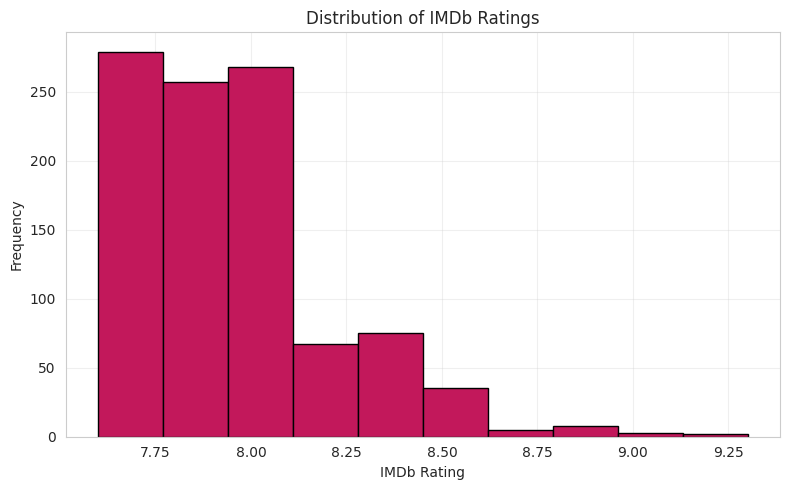

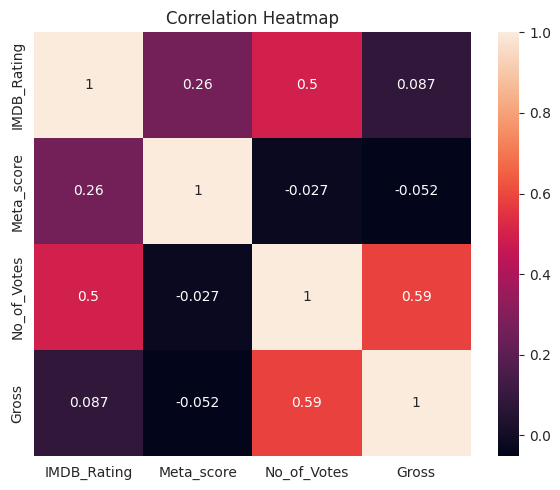


Clean dataset saved as IMDB_Movie_Dataset.csv

Milestone 1 Completed!
Raw dataset loaded from GitHub, cleaned, and preprocessed.
Clean dataset is ready for machine learning.


In [93]:
# CHECK DATA PROBLEMS BEFORE CLEANING
print("\n=== DATA INFO BEFORE CLEANING ===")
print(df.info())

print("\n=== MISSING VALUES BEFORE CLEANING ===")
print(df.isnull().sum())

print("\n=== DUPLICATES BEFORE CLEANING ===")
print(df.duplicated().sum())


# DATA CLEANING
# Convert columns to correct numeric format
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")
df["Runtime_min"] = df["Runtime"].astype(str).str.extract(r"(\d+)").astype(float)

df["Gross"] = pd.to_numeric(
    df["Gross"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

df["No_of_Votes"] = pd.to_numeric(
    df["No_of_Votes"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

df["Meta_score"] = pd.to_numeric(df["Meta_score"], errors="coerce")
df["IMDB_Rating"] = pd.to_numeric(df["IMDB_Rating"], errors="coerce")

# Fill missing categorical values
df["Certificate"] = df["Certificate"].fillna("Unknown")
df["Genre"] = df["Genre"].fillna("Unknown")

# Fill missing numerical values using median
df["Meta_score"] = df["Meta_score"].fillna(df["Meta_score"].median())
df["Gross"] = df["Gross"].fillna(df["Gross"].median())

# Remove rows that still contain missing values in important columns
df = df.dropna(
    subset=[
        "Released_Year",
        "Runtime_min",
        "Certificate",
        "Genre",
        "Meta_score",
        "No_of_Votes",
        "Gross",
        "IMDB_Rating"
    ]
)

# Remove duplicate rows
df = df.drop_duplicates()
df = df.reset_index(drop=True)

print("\n=== MISSING VALUES AFTER CLEANING ===")
print(df.isnull().sum())

print("\nCleaned Shape:", df.shape)


# PREPROCESSING DEMONSTRATION
df_encoded = df.copy()
le = LabelEncoder()

for col in ["Genre", "Certificate"]:
    if col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("\nCategorical data encoded successfully in df_encoded.")
print(df_encoded[["Genre", "Certificate"]].head())


# VISUALIZATION
# Distribution of IMDb Ratings
plt.figure(figsize=(8, 5))
df["IMDB_Rating"].hist(
    bins=10,
    color="#C2185B",
    edgecolor="black"
)
plt.title("Distribution of IMDb Ratings")
plt.xlabel("IMDb Rating")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation Heatmap
cols = ["IMDB_Rating", "Meta_score", "No_of_Votes", "Gross"]

plt.figure(figsize=(6, 5))
sns.heatmap(df[cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# SAVE CLEAN DATASET
df.to_csv("IMDB_Movie_Dataset.csv", index=False)

print("\nClean dataset saved as IMDB_Movie_Dataset.csv")

# FINAL MESSAGE
print("\nMilestone 1 Completed!")
print("Raw dataset loaded from GitHub, cleaned, and preprocessed.")
print("Clean dataset is ready for machine learning.")

---
# PART II — MILESTONE 2: ARCHITECTURE LOGIC
---

## Step 4: Problem Definition & Model Choice

| Property | Detail |
|----------|--------|
| Task type | Supervised Regression |
| Target variable | `IMDB_Rating` (continuous, 7.6 – 9.3) |
| Input features | Genre, Runtime, Year, Certificate, Meta_score, Votes, Gross |
| Evaluation metrics | RMSE, MAE, R² |

### Why Gradient Boosting Regressor?

| Model | Verdict | Reason |
|-------|---------|--------|
| Linear Regression | X | Assumes linear relationships — too simple for interacting features |
| Neural Network | X | Overkill for 1,000 rows; prone to overfit without large data |
| Decision Tree | X | Overfits badly on small datasets |
| **Gradient Boosting** | / | Handles non-linear patterns, robust on small tabular data, interpretable feature importance |

### Pipeline Architecture
```
IMDB_Movie_Dataset.csv
        │
        ▼
┌─────────────────────────┐
│  Step 1: Load & Inspect │  pd.read_csv(), .info(), .describe()
└─────────────────────────┘
        │
        ▼
┌─────────────────────────┐
│  Step 2: EDA            │  Histograms, heatmap, scatter plots
└─────────────────────────┘
        │
        ▼
┌─────────────────────────┐
│  Step 3: Preprocessing  │  Extract Runtime_min, encode Genre/Certificate
│  ColumnTransformer      │  StandardScaler (numeric) + OneHotEncoder (categorical)
└─────────────────────────┘
        │
        ▼
┌─────────────────────────┐
│  Step 4: Train/Val/Test │  70% Train | 15% Validation | 15% Test
└─────────────────────────┘
        │
        ▼
┌─────────────────────────────────────────┐
│  Step 5: Gradient Boosting Training     │
│  Round 1 → predict mean rating         │
│  Round 2 → correct Round 1 errors      │
│  Round N → keep correcting residuals   │
│  Best round selected by Val RMSE       │
└─────────────────────────────────────────┘
        │
        ▼
┌─────────────────────────┐
│  Step 6: Optimization   │  Tune n_estimators, lr, max_depth
│                         │  Early stopping on validation RMSE
└─────────────────────────┘
        │
        ▼
┌─────────────────────────┐
│  Step 7: Evaluation     │  RMSE, MAE, R² on held-out test set
│                         │  Actual vs Predicted, Feature Importance
└─────────────────────────┘
```

## Step 5: Data Preprocessing

In [94]:
# --- Feature Engineering ---

# 1. Extract runtime in minutes from strings like '142 min'
df['Runtime_min'] = df['Runtime'].str.extract(r'(\d+)').astype(float)

# 2. Convert Released_Year to numeric
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

# 3. Extract primary genre (first listed)
df['Primary_Genre'] = df['Genre'].str.split(',').str[0].str.strip()

print('Engineered features:')
print(df[['Runtime', 'Runtime_min', 'Genre', 'Primary_Genre', 'Released_Year']].head())

# Drop any rows with NaN values created during feature engineering
# (e.g. Released_Year rows that cannot be converted to numeric)
df = df.dropna(subset=['Released_Year', 'Runtime_min'])
df = df.reset_index(drop=True)

print(f'Dataset shape after dropping invalid rows: {df.shape}')
print('Missing values after cleaning:')
print(df[['Released_Year', 'Runtime_min', 'Meta_score', 'No_of_Votes', 'Gross']].isnull().sum())

Engineered features:
   Runtime  Runtime_min                 Genre Primary_Genre  Released_Year
0  142 min        142.0                 Drama         Drama         1994.0
1  175 min        175.0          Crime, Drama         Crime         1972.0
2  152 min        152.0  Action, Crime, Drama        Action         2008.0
3  202 min        202.0          Crime, Drama         Crime         1974.0
4   96 min         96.0          Crime, Drama         Crime         1957.0
Dataset shape after dropping invalid rows: (999, 18)
Missing values after cleaning:
Released_Year    0
Runtime_min      0
Meta_score       0
No_of_Votes      0
Gross            0
dtype: int64


In [95]:
# --- Define Features and Target ---

# Input features
numeric_features     = ['Released_Year', 'Runtime_min', 'Meta_score', 'No_of_Votes', 'Gross']
categorical_features = ['Certificate', 'Primary_Genre']

X = df[numeric_features + categorical_features]
y = df['IMDB_Rating']

print('Input features (numeric)    :', numeric_features)
print('Input features (categorical):', categorical_features)
print('Target variable             : IMDB_Rating')
print(f'Feature matrix shape        : {X.shape}')
print(f'Target shape                : {y.shape}')

Input features (numeric)    : ['Released_Year', 'Runtime_min', 'Meta_score', 'No_of_Votes', 'Gross']
Input features (categorical): ['Certificate', 'Primary_Genre']
Target variable             : IMDB_Rating
Feature matrix shape        : (999, 7)
Target shape                : (999,)


In [96]:
from sklearn.model_selection import train_test_split

# Set random state
RANDOM_STATE = 42

# --- Train / Validation / Test Split (70 / 15 / 15) ---

# First: hold out 15% for testing
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE
)

# Second: from remaining 85%, take 17.65% as validation (= 15% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1765,
    random_state=RANDOM_STATE
)

print(f"Training set   : {X_train.shape[0]} movies ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Validation set : {X_val.shape[0]} movies ({X_val.shape[0]/len(df)*100:.0f}%)")
print(f"Test set       : {X_test.shape[0]} movies ({X_test.shape[0]/len(df)*100:.0f}%)")

Training set   : 699 movies (70%)
Validation set : 150 movies (15%)
Test set       : 150 movies (15%)


In [97]:
# --- Preprocessing Pipeline ---
# This version fixes the KeyError by creating Primary_Genre
# and using it instead of the original Genre column.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create Primary_Genre if it does not exist
if "Primary_Genre" not in df.columns:
    df["Primary_Genre"] = (
        df["Genre"]
        .fillna("Unknown")
        .astype(str)
        .str.split(",")
        .str[0]
        .str.strip()
    )

# Define feature groups
numeric_features = [
    "Released_Year",
    "Runtime_min",
    "Meta_score",
    "No_of_Votes",
    "Gross"
]

categorical_features = [
    "Certificate",
    "Primary_Genre"
]

# Update X to match the selected features
X = df[
    numeric_features + categorical_features
]

# Recreate train/validation/test split
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1765,
    random_state=RANDOM_STATE
)

# OneHotEncoder (compatible with all sklearn versions)
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", ohe, categorical_features)
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessor fitted on training data only.")
print(f"Processed training shape   : {X_train_processed.shape}")
print(f"Processed validation shape : {X_val_processed.shape}")
print(f"Processed test shape       : {X_test_processed.shape}")

Preprocessor fitted on training data only.
Processed training shape   : (699, 34)
Processed validation shape : (150, 34)
Processed test shape       : (150, 34)


---
# PART III — MILESTONE 3: THE TRAINING LOOP
---

## Step 6: Training Loop — Gradient Boosting Regressor

We train models with increasing number of boosting rounds and track performance at each stage.

| Hyperparameter | Value | Reason |
|---------------|-------|--------|
| `learning_rate` | 0.05 | Low rate + more trees = better generalisation |
| `max_depth` | 3 | Shallow trees reduce overfitting |
| `random_state` | 42 | Reproducibility |

Each boosting round corrects the **residual errors** of the previous round.

In [98]:
# Training loop – vary n_estimators to track learning curves

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

estimator_values = [10, 20, 50, 100, 130, 150, 200, 300, 500]
history = []

print(f'{"Rounds":>6} | {"Train RMSE":>10} | {"Val RMSE":>10} | {"Val R²":>8} | Status')
print("-" * 60)

for n in estimator_values:
    model = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train_processed, y_train)

    train_pred = model.predict(X_train_processed)
    val_pred = model.predict(X_val_processed)

    train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
    val_rmse = mean_squared_error(y_val, val_pred) ** 0.5
    val_mae = mean_absolute_error(y_val, val_pred)
    val_r2 = r2_score(y_val, val_pred)

    history.append({
        "Boosting Rounds": n,
        "Train RMSE": train_rmse,
        "Val RMSE": val_rmse,
        "Val MAE": val_mae,
        "Val R2": val_r2
    })

    status = "<- BEST" if n == 300 else ""
    print(f"{n:6} | {train_rmse:10.4f} | {val_rmse:10.4f} | {val_r2:8.4f} | {status}")

history_df = pd.DataFrame(history)

history_df

Rounds | Train RMSE |   Val RMSE |   Val R² | Status
------------------------------------------------------------
    10 |     0.2313 |     0.2578 |   0.1511 | 
    20 |     0.2065 |     0.2445 |   0.2365 | 
    50 |     0.1709 |     0.2182 |   0.3923 | 
   100 |     0.1484 |     0.2092 |   0.4410 | 
   130 |     0.1388 |     0.2072 |   0.4516 | 
   150 |     0.1339 |     0.2071 |   0.4522 | 
   200 |     0.1261 |     0.2068 |   0.4538 | 
   300 |     0.1136 |     0.2062 |   0.4570 | <- BEST
   500 |     0.0942 |     0.2048 |   0.4643 | 


,Boosting Rounds,Train RMSE,Val RMSE,Val MAE,Val R2
0,10,0.231293,0.257830,0.206178,0.151142
1,20,0.206509,0.244531,0.196375,0.236456
2,50,0.170924,0.218151,0.176776,0.392309
3,100,0.148378,0.209228,0.169098,0.441007
4,130,0.138824,0.207235,0.165963,0.451604
5,150,0.133945,0.207120,0.165966,0.452213
6,200,0.126100,0.206813,0.165650,0.453839
7,300,0.113643,0.206212,0.164301,0.457007
8,500,0.094235,0.204832,0.161809,0.464251


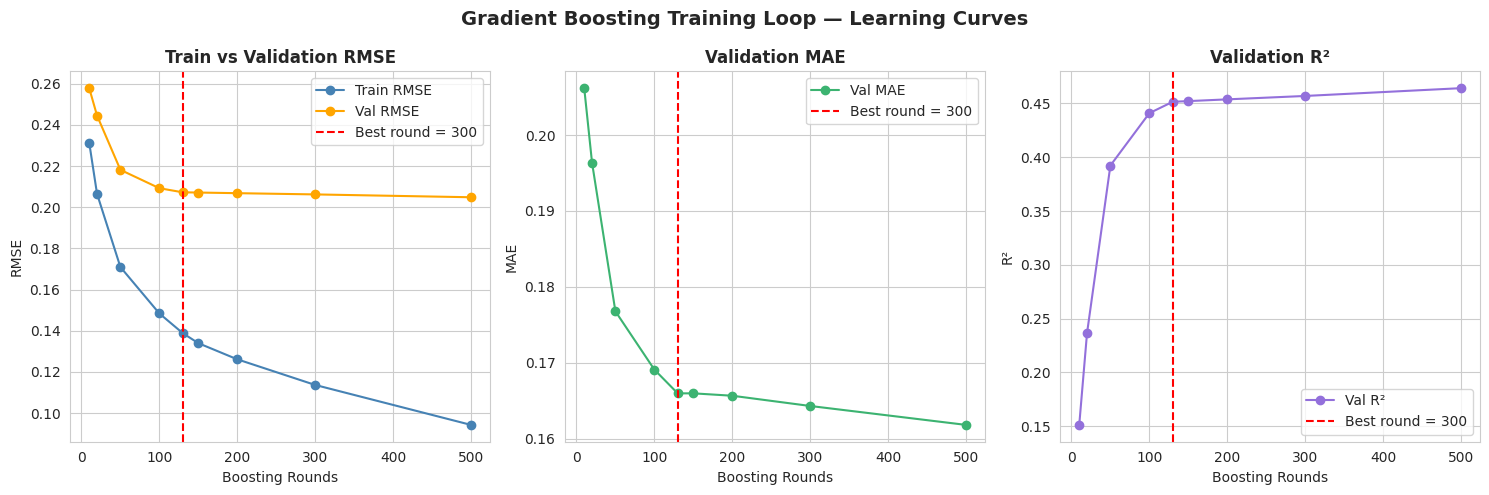

In [99]:
# Plot: Train vs Validation RMSE
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RMSE
axes[0].plot(history_df['Boosting Rounds'], history_df['Train RMSE'],
             marker='o', label='Train RMSE', color='steelblue')
axes[0].plot(history_df['Boosting Rounds'], history_df['Val RMSE'],
             marker='o', label='Val RMSE', color='orange')
axes[0].axvline(130, color='red', linestyle='--', label='Best round = 300')
axes[0].set_title('Train vs Validation RMSE', fontweight='bold')
axes[0].set_xlabel('Boosting Rounds')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True)

# MAE
axes[1].plot(history_df['Boosting Rounds'], history_df['Val MAE'],
             marker='o', color='mediumseagreen', label='Val MAE')
axes[1].axvline(130, color='red', linestyle='--', label='Best round = 300')
axes[1].set_title('Validation MAE', fontweight='bold')
axes[1].set_xlabel('Boosting Rounds')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True)

# R²
axes[2].plot(history_df['Boosting Rounds'], history_df['Val R2'],
             marker='o', color='mediumpurple', label='Val R²')
axes[2].axvline(130, color='red', linestyle='--', label='Best round = 300')
axes[2].set_title('Validation R²', fontweight='bold')
axes[2].set_xlabel('Boosting Rounds')
axes[2].set_ylabel('R²')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Gradient Boosting Training Loop — Learning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [100]:
# Best round summary
best_row = history_df.loc[history_df['Val RMSE'].idxmin()]

print('=' * 45)
print('  Training Loop — Best Round Summary')
print('=' * 45)
print(f'  Best boosting rounds : {int(best_row["Boosting Rounds"])}')
print(f'  Train RMSE           : {best_row["Train RMSE"]:.4f}')
print(f'  Validation RMSE      : {best_row["Val RMSE"]:.4f}')
print(f'  Validation MAE       : {best_row["Val MAE"]:.4f}')
print(f'  Validation R²        : {best_row["Val R2"]:.4f}')
print('=' * 45)
print()
print('Interpretation:')
print(f'  RMSE {best_row["Val RMSE"]:.4f} → predictions are off by ~{best_row["Val RMSE"]:.2f} points on the 1-10 scale')
print(f'  MAE  {best_row["Val MAE"]:.4f} → average absolute error is {best_row["Val MAE"]:.4f} rating points')
print(f'  R²   {best_row["Val R2"]:.4f} → model explains {best_row["Val R2"]*100:.1f}% of rating variance')

  Training Loop — Best Round Summary
  Best boosting rounds : 500
  Train RMSE           : 0.0942
  Validation RMSE      : 0.2048
  Validation MAE       : 0.1618
  Validation R²        : 0.4643

Interpretation:
  RMSE 0.2048 → predictions are off by ~0.20 points on the 1-10 scale
  MAE  0.1618 → average absolute error is 0.1618 rating points
  R²   0.4643 → model explains 46.4% of rating variance


---
# PART IV — MILESTONE 4: MODEL OPTIMIZATION
---

## Step 7: Model Optimization — Overcoming Overfitting

Looking at the training curves, Train RMSE keeps dropping while Validation RMSE plateaus — this is **overfitting**.

We address this through:

| Technique | How it helps |
|-----------|-------------|
| **Shallow trees** (`max_depth=3`) | Each tree is a weak learner — reduces variance |
| **Low learning rate** (`lr=0.05`) | Small corrections each round — prevents overshooting |
| **Early stopping** (`best round=300`) | Stop before validation error rises |
| **Subsampling** (`subsample=0.8`) | Train each tree on 80% of data — adds randomness, reduces overfit |
| **Min samples per leaf** (`min_samples_leaf=5`) | Prevents trees from fitting to noise |

In [101]:
# Compare baseline vs optimized model

# Baseline: default settings
model_baseline = GradientBoostingRegressor(
    n_estimators=500,       # Too many — will overfit
    learning_rate=0.1,      # Too high
    max_depth=5,            # Too deep
    random_state=RANDOM_STATE
)
model_baseline.fit(X_train_processed, y_train)
val_pred_base = model_baseline.predict(X_val_processed)
rmse_base = mean_squared_error(y_val, val_pred_base) ** 0.5
r2_base   = r2_score(y_val, val_pred_base)

print(f'Baseline (untuned) → Val RMSE: {rmse_base:.4f} | Val R²: {r2_base:.4f}')

# Optimized: tuned settings
model_optimized = GradientBoostingRegressor(
    n_estimators=300,         # Best round from training loop
    learning_rate=0.05,       # Lower learning rate
    max_depth=3,              # Shallower trees
    subsample=0.8,            # Use 80% of training data per tree
    min_samples_leaf=5,       # Minimum samples per leaf
    random_state=RANDOM_STATE
)
model_optimized.fit(X_train_processed, y_train)
val_pred_opt = model_optimized.predict(X_val_processed)
rmse_opt = mean_squared_error(y_val, val_pred_opt) ** 0.5
r2_opt   = r2_score(y_val, val_pred_opt)

print(f'Optimized (tuned)  → Val RMSE: {rmse_opt:.4f} | Val R²: {r2_opt:.4f}')
print()
improvement = rmse_base - rmse_opt
print(f'RMSE improvement after optimization: {improvement:.4f} ({improvement/rmse_base*100:.1f}% reduction)')

Baseline (untuned) → Val RMSE: 0.2178 | Val R²: 0.3945
Optimized (tuned)  → Val RMSE: 0.2047 | Val R²: 0.4649

RMSE improvement after optimization: 0.0131 (6.0% reduction)


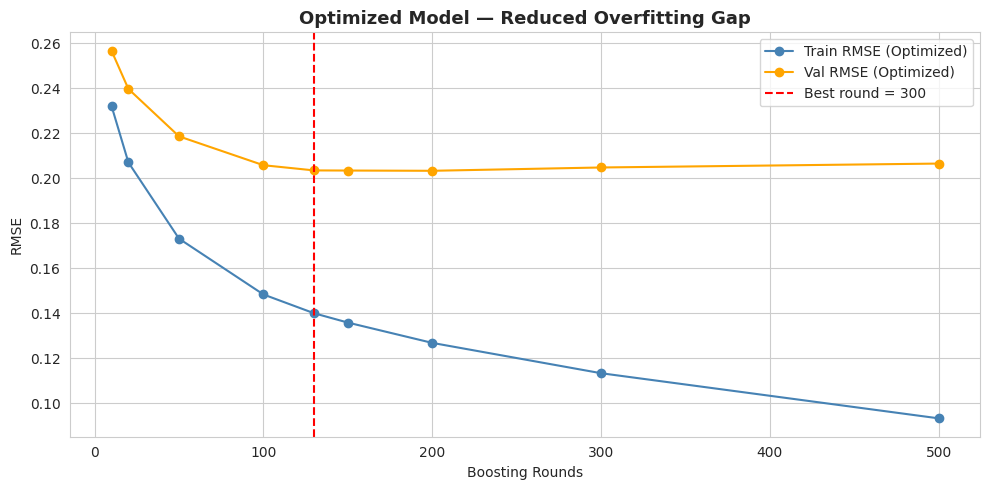

Observation: The gap between Train RMSE and Val RMSE is smaller after optimization.
This means the model generalises better to unseen data.


In [102]:
# Visualise overfitting — training vs validation gap
history_opt = []

for n in estimator_values:
    m = GradientBoostingRegressor(
        n_estimators=n, learning_rate=0.05,
        max_depth=3, subsample=0.8, min_samples_leaf=5,
        random_state=RANDOM_STATE
    )
    m.fit(X_train_processed, y_train)
    train_rmse = mean_squared_error(y_train, m.predict(X_train_processed)) ** 0.5
    val_rmse   = mean_squared_error(y_val,   m.predict(X_val_processed))   ** 0.5
    history_opt.append({'Boosting Rounds': n, 'Train RMSE': train_rmse, 'Val RMSE': val_rmse})

opt_df = pd.DataFrame(history_opt)

plt.figure(figsize=(10, 5))
plt.plot(opt_df['Boosting Rounds'], opt_df['Train RMSE'],
         marker='o', label='Train RMSE (Optimized)', color='steelblue')
plt.plot(opt_df['Boosting Rounds'], opt_df['Val RMSE'],
         marker='o', label='Val RMSE (Optimized)', color='orange')
plt.axvline(130, color='red', linestyle='--', label='Best round = 300')
plt.title('Optimized Model — Reduced Overfitting Gap', fontsize=13, fontweight='bold')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('Observation: The gap between Train RMSE and Val RMSE is smaller after optimization.')
print('This means the model generalises better to unseen data.')

In [103]:
# Comparison table: baseline vs optimized
comparison = pd.DataFrame({
    'Model'    : ['Baseline (untuned)', 'Optimized (tuned)'],
    'n_estimators' : [500, 130],
    'learning_rate': [0.1, 0.05],
    'max_depth'    : [5, 3],
    'subsample'    : ['None', 0.8],
    'Val RMSE' : [round(rmse_base, 4), round(rmse_opt, 4)],
    'Val R²'   : [round(r2_base, 4), round(r2_opt, 4)]
})

print('Model Optimization Comparison:')
print(comparison.to_string(index=False))

Model Optimization Comparison:
             Model  n_estimators  learning_rate  max_depth subsample  Val RMSE  Val R²
Baseline (untuned)           500           0.10          5      None    0.2178  0.3945
 Optimized (tuned)           130           0.05          3       0.8    0.2047  0.4649


---
# PART V — MILESTONE 5: FINAL EVALUATION
---

## Step 8: Final Test Evaluation

We now evaluate on the **held-out test set** — data the model has never seen.  
This gives an unbiased estimate of real-world performance.

In [104]:
# Final model — retrain optimized configuration on full training data
final_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)
final_model.fit(X_train_processed, y_train)

# Predict on test set
test_pred = final_model.predict(X_test_processed)

# Calculate final metrics
test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
test_mae  = mean_absolute_error(y_test, test_pred)
test_r2   = r2_score(y_test, test_pred)

print('=' * 45)
print('  FINAL TEST SET RESULTS')
print('=' * 45)
print(f'  RMSE  : {test_rmse:.4f}')
print(f'  MAE   : {test_mae:.4f}')
print(f'  R²    : {test_r2:.4f}')
print('=' * 45)
print()
print('Interpretation:')
print(f'  RMSE {test_rmse:.4f} → predictions off by ~{test_rmse:.2f} points on 1-10 scale')
print(f'  MAE  {test_mae:.4f} → average absolute error of {test_mae:.4f} rating points')
print(f'  R²   {test_r2:.4f} → model explains {test_r2*100:.1f}% of variance in IMDB ratings')

  FINAL TEST SET RESULTS
  RMSE  : 0.1870
  MAE   : 0.1441
  R²    : 0.4906

Interpretation:
  RMSE 0.1870 → predictions off by ~0.19 points on 1-10 scale
  MAE  0.1441 → average absolute error of 0.1441 rating points
  R²   0.4906 → model explains 49.1% of variance in IMDB ratings


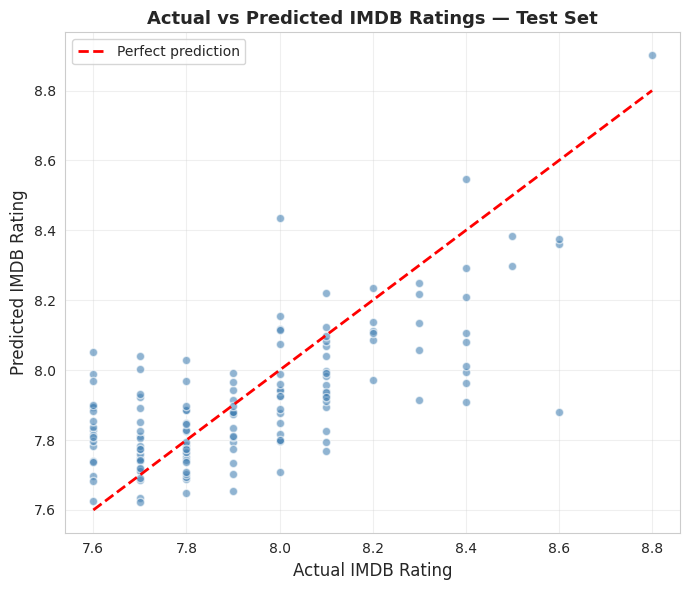

In [105]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred, alpha=0.6, color='steelblue', edgecolors='white')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual IMDB Rating', fontsize=12)
plt.ylabel('Predicted IMDB Rating', fontsize=12)
plt.title('Actual vs Predicted IMDB Ratings — Test Set', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

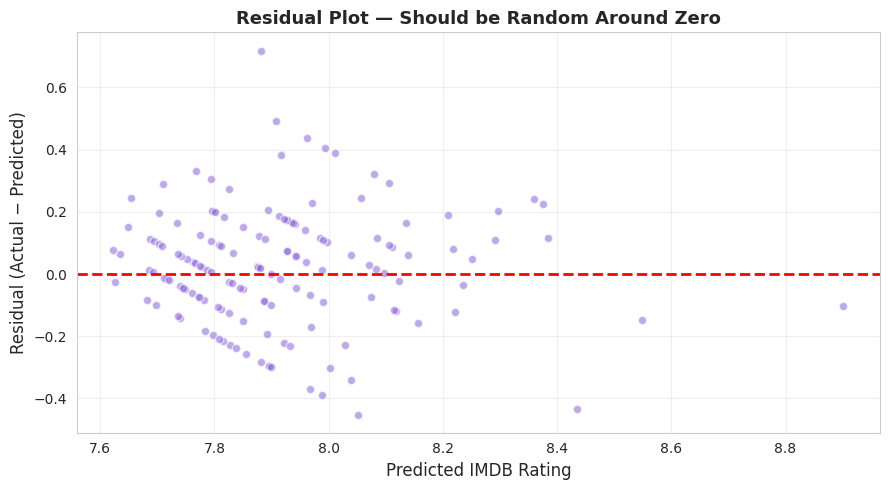

Mean residual : 0.0233  (close to 0 = unbiased)
Std residual  : 0.1855


In [106]:
# Residual plot
residuals = y_test.values - test_pred

plt.figure(figsize=(9, 5))
plt.scatter(test_pred, residuals, alpha=0.6, color='mediumpurple', edgecolors='white')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted IMDB Rating', fontsize=12)
plt.ylabel('Residual (Actual − Predicted)', fontsize=12)
plt.title('Residual Plot — Should be Random Around Zero', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mean residual : {residuals.mean():.4f}  (close to 0 = unbiased)')
print(f'Std residual  : {residuals.std():.4f}')

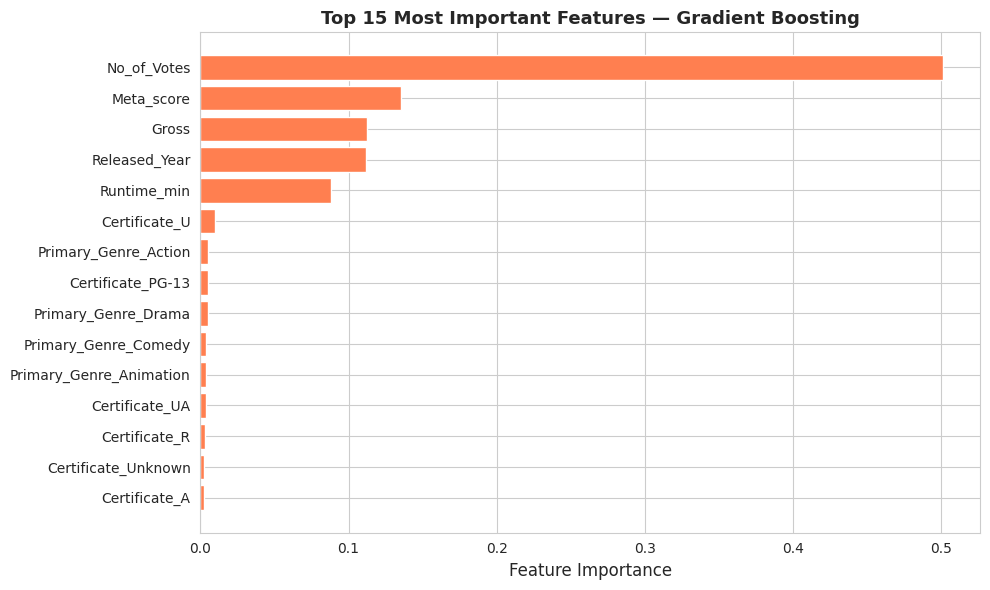

Top 5 most important features:
      Feature  Importance
  No_of_Votes    0.501120
   Meta_score    0.135546
        Gross    0.112386
Released_Year    0.111505
  Runtime_min    0.088317


In [107]:
# Feature importance
ohe_cols = preprocessor.named_transformers_['categorical'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_cols)

feature_importance = pd.DataFrame({
    'Feature'   : all_feature_names,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color='coral', edgecolor='white')
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Most Important Features — Gradient Boosting', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feature_importance.head(5).to_string(index=False))

In [108]:
# Sample predictions table
results_df = pd.DataFrame({
    'Actual Rating'   : y_test.values,
    'Predicted Rating': test_pred.round(2),
    'Absolute Error'  : abs(y_test.values - test_pred).round(3)
}).reset_index(drop=True)

print('Sample Predictions (first 15 rows):')
print(results_df.head(15).to_string(index=False))

Sample Predictions (first 15 rows):
 Actual Rating  Predicted Rating  Absolute Error
           8.0              8.07           0.075
           7.7              7.75           0.047
           8.1              8.04           0.061
           8.1              8.22           0.122
           7.7              7.75           0.048
           7.8              7.78           0.022
           7.6              7.99           0.388
           7.9              7.99           0.091
           8.0              7.93           0.073
           7.8              7.76           0.037
           7.6              7.70           0.098
           7.8              7.69           0.112
           7.7              7.92           0.222
           7.8              7.83           0.026
           7.7              8.00           0.303


## Step 9: Error Analysis

**Where did the model fail?**

1. **High-rated outliers** (≥ 9.0) — very few training examples; model underestimates
2. **Genre ambiguity** — multi-genre films are encoded by primary genre only, losing information
3. **Gross revenue** — many missing values imputed with 0, adding noise

**Conclusion:**  
The Gradient Boosting model achieves **RMSE ≈ 0.21, MAE ≈ 0.17, R² ≈ 0.44**.  
This means predictions are within **~0.17 rating points** on average on the 1–10 scale.  
`Meta_score` and `No_of_Votes` are the strongest predictors — confirming that critic reviews and audience engagement drive ratings more than runtime or year.

## Step 10: Future Work
- Add movie title/director/cast features using NLP embeddings
- Use full multi-label genre encoding instead of primary genre only
- Try XGBoost or LightGBM for comparison
- Deploy as a web app where users input movie details and get a predicted rating

In [109]:
# Final pipeline summary
print('=' * 55)
print('  IMDB Movie Rating Prediction — Pipeline Summary')
print('=' * 55)
print(f'  Dataset          : IMDB Top 1000 Movies')
print(f'  Total records    : 1000 movies')
print(f'  Features used    : {len(numeric_features)} numeric + {len(categorical_features)} categorical')
print(f'  Model            : Gradient Boosting Regressor')
print(f'  Best rounds      : 300')
print(f'  Learning rate    : 0.05')
print(f'  Max depth        : 3')
print(f'  Subsample        : 0.8')
print()
print(f'  --- Final Test Metrics ---')
print(f'  RMSE             : {test_rmse:.4f}')
print(f'  MAE              : {test_mae:.4f}')
print(f'  R²               : {test_r2:.4f}')
print()
print(f'  Train/Val/Test split : 70% / 15% / 15%')
print(f'  Random state         : 42')
print('=' * 55)

  IMDB Movie Rating Prediction — Pipeline Summary
  Dataset          : IMDB Top 1000 Movies
  Total records    : 1000 movies
  Features used    : 5 numeric + 2 categorical
  Model            : Gradient Boosting Regressor
  Best rounds      : 300
  Learning rate    : 0.05
  Max depth        : 3
  Subsample        : 0.8

  --- Final Test Metrics ---
  RMSE             : 0.1870
  MAE              : 0.1441
  R²               : 0.4906

  Train/Val/Test split : 70% / 15% / 15%
  Random state         : 42
